# Iterative extended Lengyel solver vs experiment

Compares the inverse iterative extended Lengyel solver against two experimental datasets:

* **NME21** (Henderson et al, NME 2021): the nitrogen concentration required to detach,
  for ASDEX Upgrade and JET, using the density-constrained inverse model.
* **NF23** (Henderson et al, NF 2023): the summed (N + Ne + Ar) impurity concentration
  required to reach the measured target electron temperature and divertor neutral
  pressure, for ASDEX Upgrade mixed-seeding discharges, using the
  pressure-constrained inverse model.

One figure per dataset per divertor broadening factor $b_{div} \in \{1.8, 3.0\}$ (4 figures).

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import warnings
from cfspopcon.named_options import AtomicSpecies
from cfspopcon.unit_handling import UnitStrippedWarning, magnitude_in_units, ureg

from extended_lengyel.directories import output_dir
from extended_lengyel.iterative_solver.analysis import calc_cz, calc_impurity_concentration
from extended_lengyel.iterative_solver.impurities import build_impurity_interpolators, load_atomic_data
from extended_lengyel.iterative_solver.load_data import load_nf23_data, load_nme21_data
from extended_lengyel.iterative_solver.plotting import (
    add_identity_guides,
    plot_error_regions_by_category,
    plot_with_error_regions,
)

# Treat unit-stripping warnings as errors
warnings.filterwarnings("error", category=UnitStrippedWarning)

atomic_data = load_atomic_data("radas")
bdiv_values = [1.8, 3.0]

## Comparison to Henderson et al, NME 2021

Pure-nitrogen seeding with a deuterium background; the inverse model solves for the
nitrogen concentration required to reach $T_{e,t}$ = 2.34 eV at the measured
separatrix density and power.

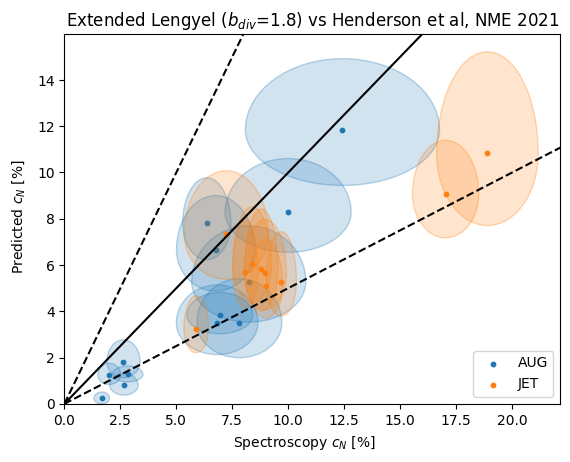

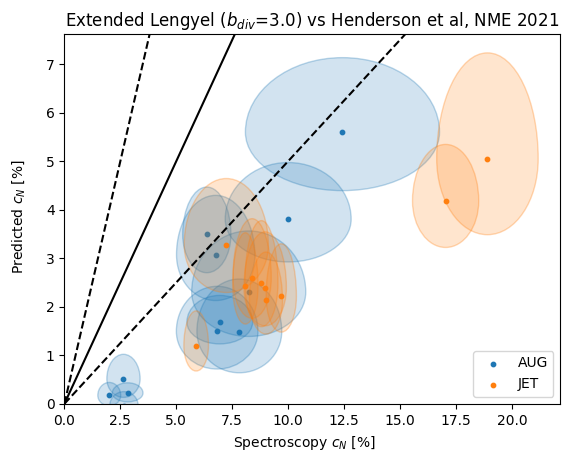

In [2]:
nme21_data = load_nme21_data()
nme21_data["AUG"]["major_radius"] = 1.65 * ureg.m
nme21_data["JET"]["major_radius"] = 2.96 * ureg.m

seed_impurities = build_impurity_interpolators([AtomicSpecies.Nitrogen], [1.0], atomic_data)
fixed_impurities = build_impurity_interpolators([AtomicSpecies.Deuterium], [1.0], atomic_data)

for bdiv in bdiv_values:

    fig, ax = plt.subplots()

    sim_data = {
        machine: calc_cz(nme21_data[machine], seed_impurities, fixed_impurities, divertor_broadening_factor=bdiv)
        for machine in ["AUG", "JET"]
    }

    for i, machine in enumerate(["AUG", "JET"]):
        plot_with_error_regions(
            ax=ax,
            x_ds=nme21_data[machine],
            x_key="nitrogen_concentration",
            x_units="%",
            y_ds=sim_data[machine],
            y_key="nitrogen_concentration",
            y_units="%",
            label=machine,
            color=f"C{i}",
        )

    ax.set_title(f"Extended Lengyel ($b_{{div}}$={bdiv}) vs Henderson et al, NME 2021")
    ax.legend(loc="lower right")

    fig.text(0.5, 0.02, "Spectroscopy $c_N$ [%]", ha="center")
    fig.text(0.04, 0.5, "Predicted $c_N$ [%]", va="center", rotation="vertical")

    ax.set_xlim(left=0.0)
    ax.set_ylim(bottom=0.0)
    add_identity_guides(ax)

    fig.savefig(output_dir / f"iterative_lengyel_bdiv={bdiv}_vs_NME21.png", dpi=300, bbox_inches="tight")

## Comparison to Henderson et al, NF 2023

Mixed N/Ne/Ar seeding with a deuterium background; the pressure-constrained inverse
model solves for the summed impurity concentration required to reach the measured
target electron temperature and divertor neutral pressure.

In [3]:
nf23_data = load_nf23_data()

# Drop outlier
nf23_data = nf23_data.where(magnitude_in_units(nf23_data["nitrogen_concentration"], ureg.percent) < 10.0, drop=True)

nf23_data["summed_impurity_concentration"] = (
    nf23_data["nitrogen_concentration"] + nf23_data["neon_concentration"] + nf23_data["argon_concentration"]
)
nf23_data["summed_impurity_concentration_err"] = (
    nf23_data["nitrogen_concentration_err"] + nf23_data["neon_concentration_err"] + nf23_data["argon_concentration_err"]
)

seeding_types = {4: "N", 1: "N + Ne", 2: "Ar", 3: "N + Ar", 5: "unseeded"}

# Machine geometry (ASDEX Upgrade)
nf23_data["major_radius"] = 1.65 * ureg.m
nf23_data["minor_radius"] = 0.5 * ureg.m
nf23_data["elongation"] = 1.7
nf23_data["triangularity"] = 0.23
nf23_data["parallel_connection_length"] = 12.0 * ureg.m
nf23_data["divertor_length"] = 0.25 * nf23_data["parallel_connection_length"]
nf23_data["magnetic_field_on_axis"] = 2.5 * ureg.T
nf23_data["plasma_current"] = 1.0 * ureg.MA

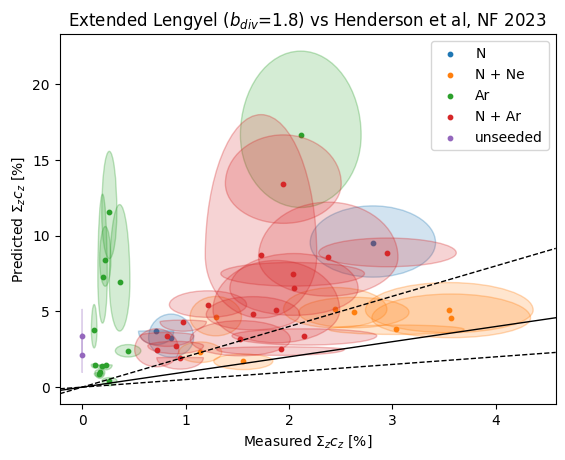

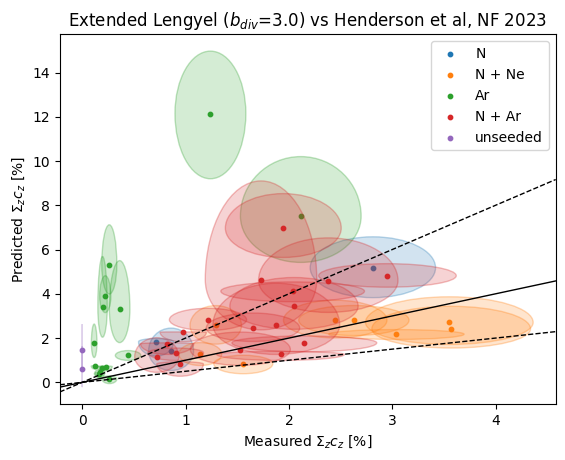

In [4]:
for bdiv in bdiv_values:

    sim_data = nf23_data.groupby("index").apply(
        calc_impurity_concentration,
        atomic_data=atomic_data,
        fixed=fixed_impurities,
        iterations=50,
        calc_uncertainty=True,
        divertor_broadening_factor=bdiv,
    )

    fig, ax = plt.subplots()

    plot_error_regions_by_category(
        ax=ax,
        x_ds=nf23_data,
        x_key="summed_impurity_concentration",
        x_units="%",
        y_ds=sim_data,
        y_key="summed_impurity_concentration",
        y_units="%",
        categories=seeding_types,
        category_data=nf23_data["seeding_type"],
        extra_mask=sim_data["converged"],
    )

    add_identity_guides(ax, linewidth=1.0)
    ax.legend()
    ax.set_xlabel("Measured $\\Sigma_z c_z$ [%]")
    ax.set_ylabel("Predicted $\\Sigma_z c_z$ [%]")
    ax.set_title(f"Extended Lengyel ($b_{{div}}$={bdiv}) vs Henderson et al, NF 2023")

    fig.savefig(output_dir / f"iterative_lengyel_bdiv={bdiv}_vs_NF23.png", dpi=300, bbox_inches="tight")